<a href="https://colab.research.google.com/github/abdulrahman0700/Industrial_Predictive_Maintenance_Elevvo_internship/blob/main/Notebooks/02_Analyze.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**PACE Stages**

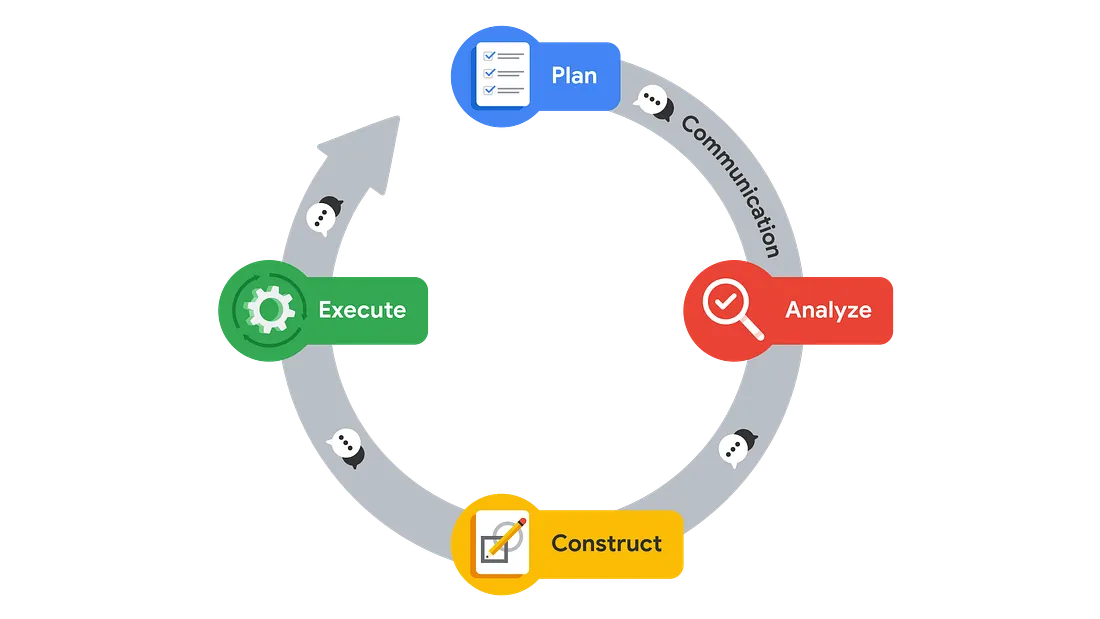

# **pAce : Analyzing Stage**

We can complete this this stage by these three main topics :


*   Cleaning the data (handling missing values, duplicates, outliers,Imbalanced if it existed)
*   Exploratory data analysis (EDA) — looking at distributions, correlations, patterns
*   Checking assumptions needed for later modeling


### **in Reflecting on these topics above by answering these Questions**

1.   What did you observe about Features / the relationships between Features?

>> 1. There is a **Strong Linear Relationship** Between **Air_temperature[K]** and **Process_temperature[K]**
>> 2. There is **high Linear Relationship** between **Machine Failurs** and **Tool_Wear_Failure[TWF]** and **Overstrain_Failure[OSF]** and **Heat_Dissipation_Failure[HDF]** . it means that Most of machine Failing happen because **Tool Wear** , **Overstrain** and **Heat_Dissipation**
>> 3. There is more than just one Type of machine Failures happend at the same time
>> 4. there is observed cluster of data points that most machine Failed in specific range in Torque[NM] (from almost 43 NM  to 77.2 NM )and Tool Wear[min] (from almost 160 min to 249 min)

>> 5. There is Imbalanced in target feature "Machine_failure" 93.6% of data belong to class No Failure (0) on the contrary 6.4% belong to class Failure(1)

>> 6. Most of Machine Types that failed is L Type about 71.8% and for M Type 20.8 % failed and for H Type 7.4%

2.   What do you observe about the distributions in the data?

>> Air_temperature[K] Feature follows **Normal Distribution**

>> Process_temperature[K] Feature Follows **Normal Distribution**

>> Rotational_speed[rpm] Feature Follows **Normal Distribution**

>> Tool_Wear Feature Follows **Uniform Distribution**

3.   What transformations did you make with your data? Why did you chose to make those decisions?

>> transformation number 1 ---> I first Checked the Null values in the data and it seems that it don't have any null values

>> why ? ------> because null values will cases Error through Constract Stage during building the machine Learning model

>> transformation number 2 ---> I Renamed some of unclear columns

>> why ? -----> because it for better understanding and Readability

>> transformation number 3 -----> I checked the duplicated values

>> why ? -----> because they would artificially inflate certain patterns in the attrition rate, potentially biasing the model.

>> transformation number 4 ------> For the Outliers I Checked The Maximum and Minimum values

>> why ? -----> in this dataset, extreme Torque and Tool Wear values are often the actual mechanism of failure — a machine doesn't fail at "normal" torque, it fails when torque spikes. If you cap those spikes to the "normal" range before training, you're literally erasing the pattern the model needs to learn. This is a common mistake: outlier removal is meant for garbage/impossible values (e.g. a negative temperature reading), not for extreme-but-real physical events.

4.   What are some purposes of EDA before constructing a predictive model?

> 1. Understand the structure and content of the data

>>> Get familiar with the number of rows/columns, data types, and what each variable actually represents before doing anything else.

> 2. Identify data quality issues

>>> Spot missing values, duplicates, inconsistent formatting, and incorrect data types — all things you need to fix before a model can use the data properly.

> 3. Detect outliers and anomalies

>>> Find unusual values that could distort model training (e.g., a negative age, or an employee with 400 hours worked in a month) and decide whether to keep, remove, or transform them.

> 4. Understand the distribution of each Feature

>>> Check whether features are normally distributed, skewed, or uniform — this affects which models and preprocessing steps (like scaling or transformation) are appropriate.

> 5. Explore relationships between variables

>>> Use correlation matrices, scatterplots, or groupby summaries to see which features might actually be predictive of your target variable, and which are redundant or irrelevant.

> 6. Check for class imbalance (in classification problems)

>>> Like in the Salifort Motors case — seeing that "left" is heavily imbalanced (few employees leave vs. many stay) tells you upfront that you'll need special handling (resampling, class weights, different evaluation metrics) later.

> 7. Inform feature engineering decisions

>>> EDA often reveals opportunities to create new features (e.g., combining columns, binning continuous variables) or reveals that some existing features aren't useful and can be dropped.

> 8. Validate assumptions the model will rely on

>>> Many models (like linear/logistic regression) assume things like no multicollinearity, roughly normal residuals, or linear relationships — EDA is where you check whether those assumptions hold.

> 9. Avoid data leakage

>>> By deeply understanding what each column represents and when it's available, you're less likely to accidentally include a feature that "leaks" information from the future or from the target itself.

> 10. Build stakeholder trust and communicate findings early

>>> In a business context, EDA findings (charts, summary stats) are often what you present to stakeholders before modeling even starts, to confirm the problem framing makes sense and get buy-in.

5.   What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
>> this source of the Datasets made me understand the data better "https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020"
6.   Do you have any ethical considerations in this stage?
> there is not Ethical Consideration

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [54]:
# Fetching the data
df = pd.read_csv("/content/ai4i_predictive_maintenance.csv")

# Data Exploration and Preprocessing

In [55]:
# checking for null values
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


In [56]:
# Checking for duplicated values
df.duplicated().sum()

np.int64(0)

# Renaming the columns
As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [57]:
# renaming the columns for better format and  Readability
for index,col in enumerate(df.columns):
  col = col.replace(" ","_")
  df.rename(columns={df.columns[index]:col},inplace=True)


df.rename(columns={"TWF":"Tool_Wear_Failure[TWF]",
                   "HDF":"Heat_Dissipation_Failure[HDF]",
                   "PWF":"Power_Failure[PWF]",
                   "OSF":"Overstrain_Failure[OSF]",
                   "RNF":"Random_Failures[RNF]"},inplace=True)


In [58]:
# showing the first 5 rows
df.head()

,UDI,Product_ID,Type,Air_temperature_[K],Process_temperature_[K],Rotational_speed_[rpm],Torque_[Nm],Tool_wear_[min],Machine_failure,Tool_Wear_Failure[TWF],Heat_Dissipation_Failure[HDF],Power_Failure[PWF],Overstrain_Failure[OSF],Random_Failures[RNF]
0,1,L70598,L,297.9,307.1,1525,20.3,238,0,0,0,0,0,0
1,2,H76399,H,298.6,307.8,1384,32.3,249,0,0,0,0,0,0
2,3,M37684,M,305.0,314.1,1958,36.3,67,0,0,0,0,0,0
3,4,L78591,L,300.3,309.7,1009,46.8,248,1,0,0,0,1,0
4,5,L87722,L,300.7,311.6,1863,38.6,133,0,0,0,0,0,0


In [59]:
# Checking the Standardizing categorical values
print(df.Machine_failure.unique())

[0 1]


In [60]:
# checking for the counts of column 'machine failure' values
df.Machine_failure.value_counts()

,count
Machine_failure,
0,9362
1,638


> # **it seems that we have Imbalance Data**




In [61]:
"""
describtion: Removing outliers from the data

args : numerical target data

return: data without outliers

"""

"""
def outlire(col:list):
  for c in col:
    quantile_25 = df[c].quantile(0.25)
    quantile_75 = df[c].quantile(0.75)

    IQR = quantile_75 - quantile_25

    lower_bound = quantile_25 - (1.5 * IQR)
    upper_bound = quantile_75 + (1.5 * IQR)

    df[c] = df[c].apply(lambda x:upper_bound if x > upper_bound else x)
    df[c] = df[c].apply(lambda x:lower_bound if x < lower_bound else x)

machine_feature = ["Air_temperature[K]","Process_temperature[K]","Rotational_speed[rpm]","Torque[Nm]","Tool_wear[min]"]
outlire(machine_feature)

"""

machine_feature = ["Air_temperature_[K]","Process_temperature_[K]","Rotational_speed_[rpm]","Torque_[Nm]","Tool_wear_[min]"]

for col in machine_feature:
    print(f"{col}\n has a minimum {df[col].min()}  and maximum {df[col].max()}")

Air_temperature_[K]
 has a minimum 292.3  and maximum 309.0
Process_temperature_[K]
 has a minimum 301.1  and maximum 320.5
Rotational_speed_[rpm]
 has a minimum 887  and maximum 2171
Torque_[Nm]
 has a minimum 2.9  and maximum 77.2
Tool_wear_[min]
 has a minimum 0  and maximum 249


In [62]:
failure_types = ["Tool_Wear_Failure[TWF]", "Heat_Dissipation_Failure[HDF]",
                  "Power_Failure[PWF]", "Overstrain_Failure[OSF]", "Random_Failures[RNF]"]

# individual counts
for col in failure_types:
    print(col, df[df['Machine_failure']==1][col].sum())

# combo counts (rows with more than one flag = 1)
combo_count = (df[failure_types].sum(axis=1) > 1).sum()
print("Rows with more than one failure type:", combo_count)

Tool_Wear_Failure[TWF] 154
Heat_Dissipation_Failure[HDF] 158
Power_Failure[PWF] 22
Overstrain_Failure[OSF] 339
Random_Failures[RNF] 10
Rows with more than one failure type: 45


In [63]:
# The counts of failure and non-failure  for Every type we have
for f_m in failure_types:
  print(df[f_m].value_counts())

Tool_Wear_Failure[TWF]
0    9846
1     154
Name: count, dtype: int64
Heat_Dissipation_Failure[HDF]
0    9842
1     158
Name: count, dtype: int64
Power_Failure[PWF]
0    9978
1      22
Name: count, dtype: int64
Overstrain_Failure[OSF]
0    9661
1     339
Name: count, dtype: int64
Random_Failures[RNF]
0    9990
1      10
Name: count, dtype: int64


In [64]:
# Grouping by the Types of Failures that happened to the machines
df.groupby(["Power_Failure[PWF]",
            "Random_Failures[RNF]",
            "Heat_Dissipation_Failure[HDF]",
            "Tool_Wear_Failure[TWF]",
            "Overstrain_Failure[OSF]"])['Machine_failure'].agg(["count",'max','min'])

count  \
Power_Failure[PWF] Random_Failures[RNF] Heat_Dissipation_Failure[HDF] Tool_Wear_Failure[TWF] Overstrain_Failure[OSF]          
0                  0                    0                             0                      0                         9362   
                                                                                             1                          299   
                                                                      1                      0                          119   
                                                                                             1                           32   
                                        1                             0                      0                          153   
                                                                                             1                            1   
                                                                      1                      0                            2   
                   1                    0                             0                      0                            8   
                                                                                             1                            1   
                                                                      1                      0                            1   
1                  0                    0                             0                      0                           14   
                                                                                             1                            6   
                                        1                             0                      0                            2   

                                                                                                                      max  \
Power_Failure[PWF] Random_Failures[RNF] Heat_Dissipation_Failure[HDF] Tool_Wear_Failure[TWF] Overstrain_Failure[OSF]        
0                  0                    0                             0                      0                          0   
                                                                                             1                          1   
                                                                      1                      0                          1   
                                                                                             1                          1   
                                        1                             0                      0                          1   
                                                                                             1                          1   
                                                                      1                      0                          1   
                   1                    0                             0                      0                          1   
                                                                                             1                          1   
                                                                      1                      0                          1   
1                  0                    0                             0                      0                          1   
                                                                                             1                          1   
                                        1                             0                      0                          1   

                                                                                                                      min  
Power_Failure[PWF] Random_Failures[RNF] Heat_Dissipation_Failure[HDF] Tool_Wear_Failure[TWF] Overstrain_Failure[OSF]       
0                  0                    0                             0                 

In [65]:
# Creating a copy of our data for testing and visualiztion and not modifying with original data
df_copy = df.copy()

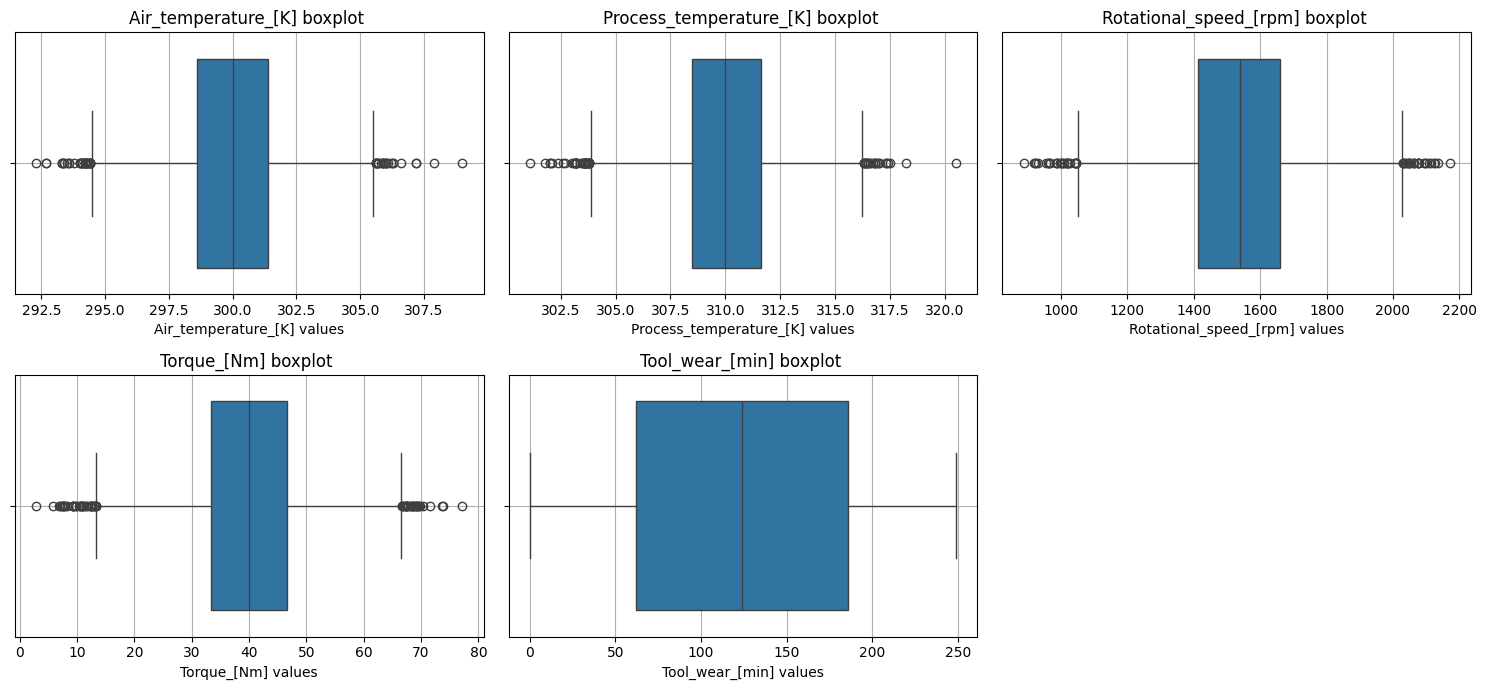

In [66]:
# Creating Box Plots for identify the mean , median , First-quartile , third-quartile
fig , axis = plt.subplots(2,3,figsize=(15,7))
for i in range(len(machine_feature)):
  row , col = i // 3 , i % 3
  sns.boxplot(x=df_copy[machine_feature[i]],ax=axis[row,col])
  axis[row,col].set_title(f"{machine_feature[i]} boxplot ")
  axis[row,col].set_xlabel(f"{machine_feature[i]} values")
  axis[row,col].grid()
axis[1,2].axis('off')
plt.tight_layout()
plt.show()

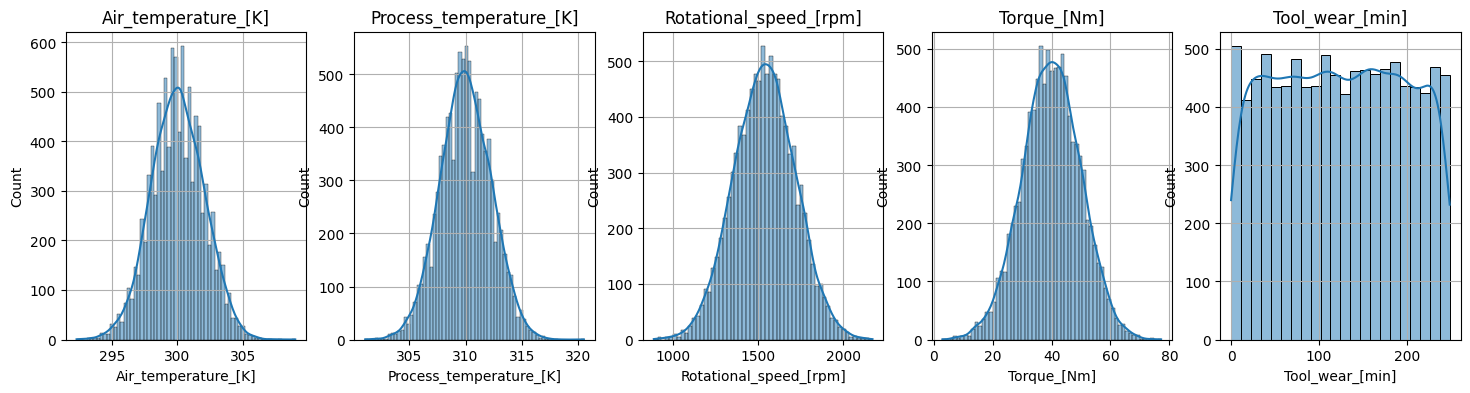

In [67]:
# Distirbution on the numrtical values
fig ,axis = plt.subplots(1,5,figsize=(18,4))
for i in range(len(machine_feature)):
  sns.histplot(df_copy[machine_feature[i]],kde=True,ax=axis[i])
  axis[i].set_title(machine_feature[i])
  axis[i].set_xlabel(machine_feature[i])
  axis[i].grid()
plt.show()

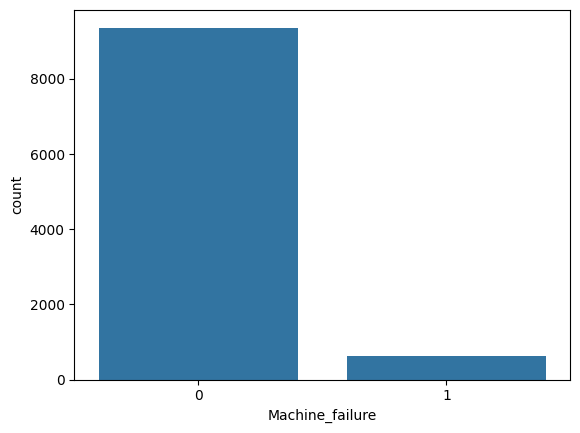

In [68]:
# counts of machine failues
sns.countplot(df,x='Machine_failure')
plt.show()

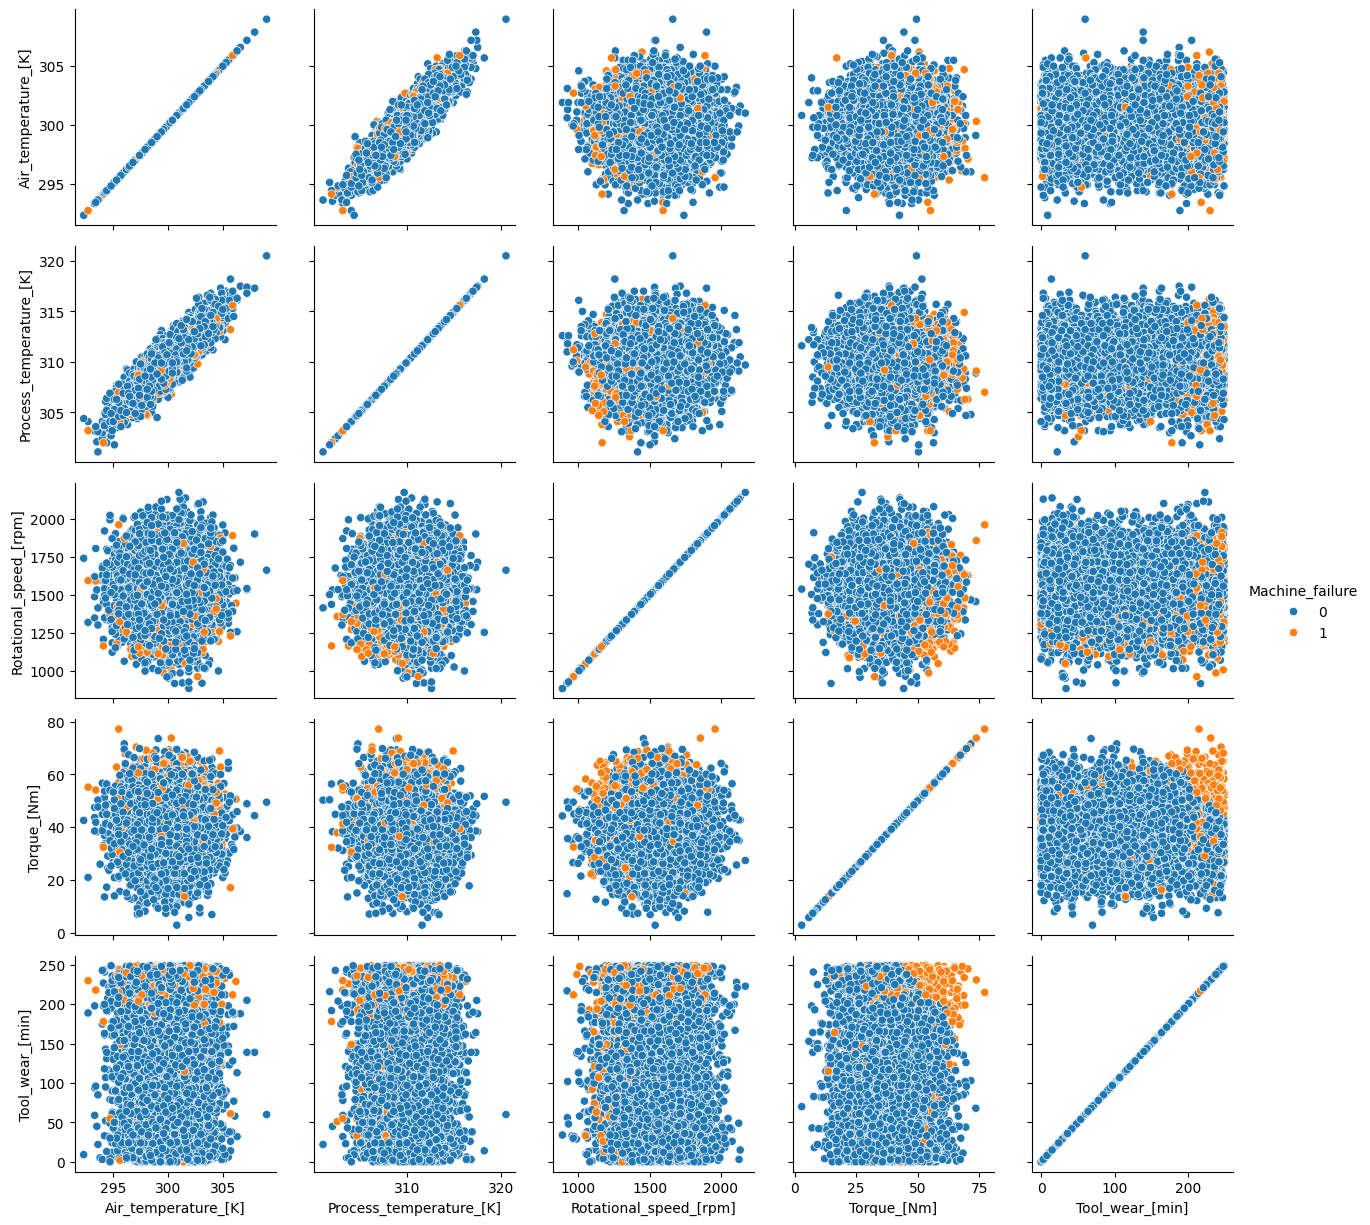

In [71]:
sns.PairGrid(df_copy[['Air_temperature_[K]',
       'Process_temperature_[K]', 'Rotational_speed_[rpm]', 'Torque_[Nm]',
       'Tool_wear_[min]', 'Machine_failure']],hue="Machine_failure").map(sns.scatterplot).add_legend()
plt.show()

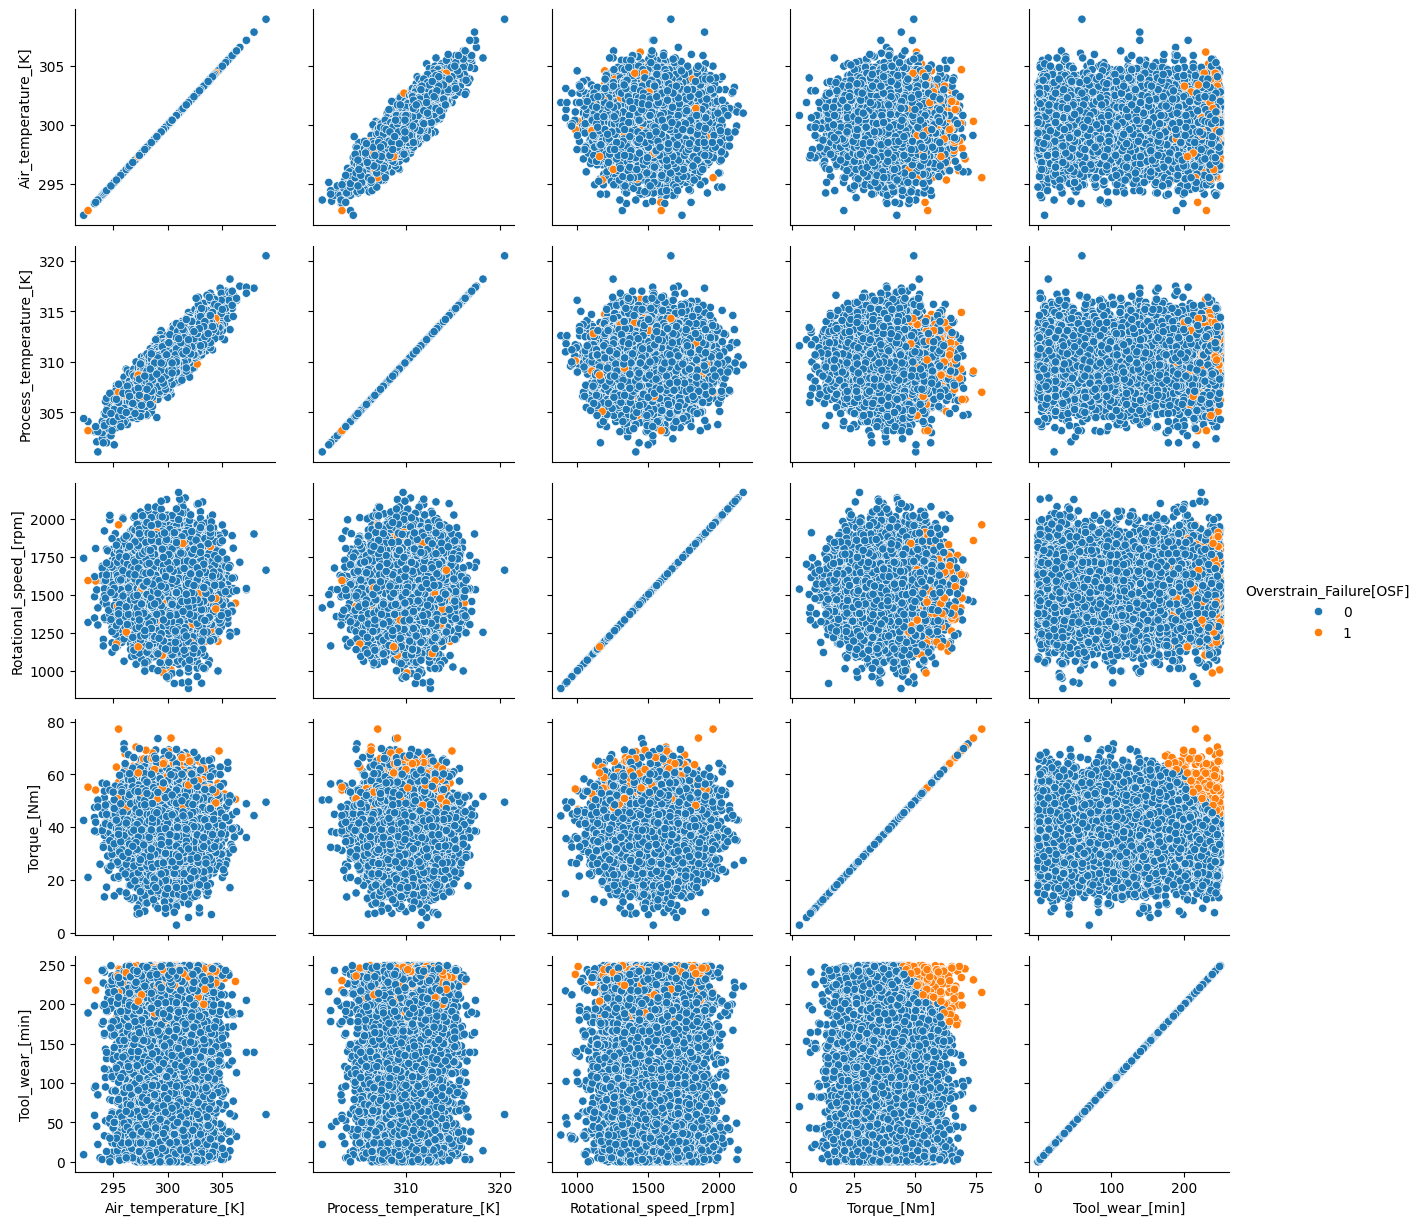

In [72]:
sns.PairGrid(df_copy[['Air_temperature_[K]',
       'Process_temperature_[K]', 'Rotational_speed_[rpm]', 'Torque_[Nm]',
       'Tool_wear_[min]','Overstrain_Failure[OSF]']],hue="Overstrain_Failure[OSF]").map(sns.scatterplot).add_legend()
plt.show()

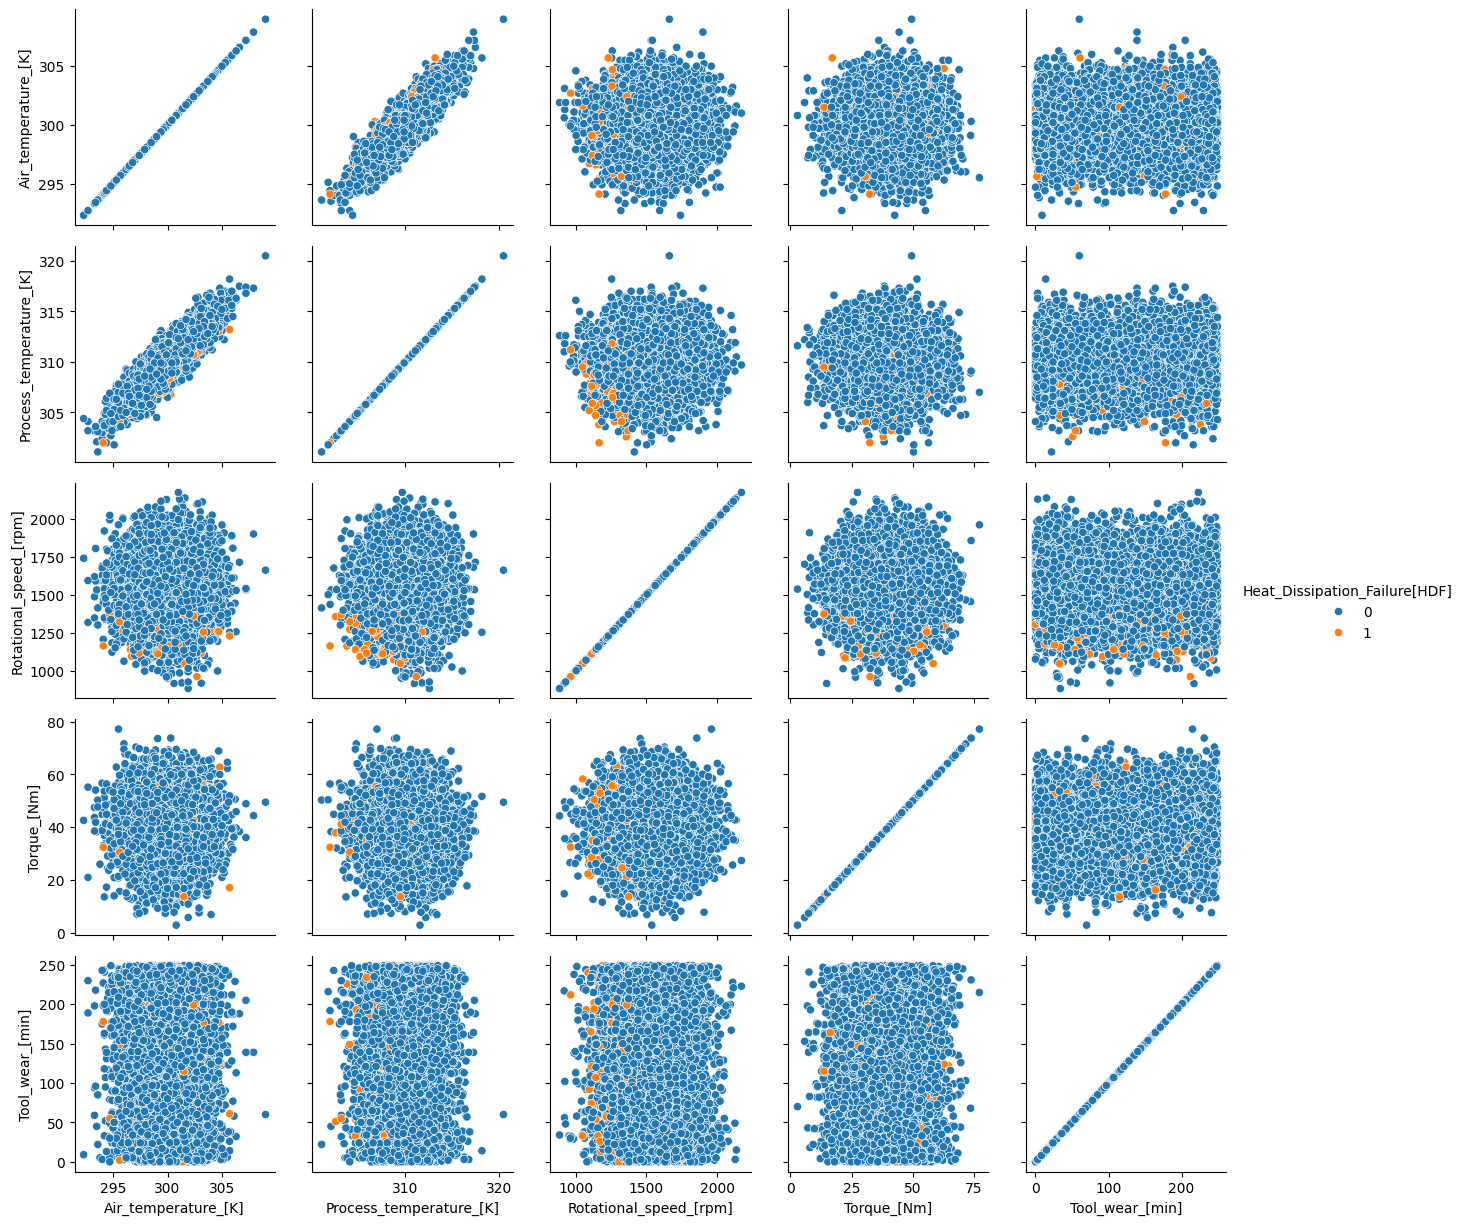

In [73]:
sns.PairGrid(df_copy[['Air_temperature_[K]',
       'Process_temperature_[K]', 'Rotational_speed_[rpm]', 'Torque_[Nm]',
       'Tool_wear_[min]','Heat_Dissipation_Failure[HDF]']],hue="Heat_Dissipation_Failure[HDF]").map(sns.scatterplot).add_legend()
plt.show()

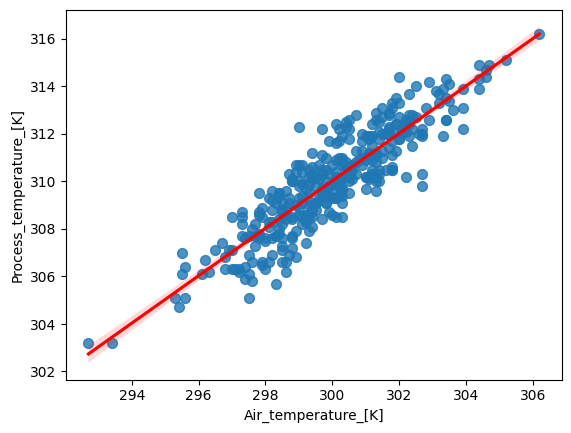

In [74]:
# showing the relation between air temperature and Process temperature with only data that have failed caused Overstrain
df_Overstrain_failure = df[df['Overstrain_Failure[OSF]'] == 1]
sns.regplot(df_Overstrain_failure,x='Air_temperature_[K]',y="Process_temperature_[K]",scatter_kws={'s':50},line_kws={'color':'red'})
plt.show()

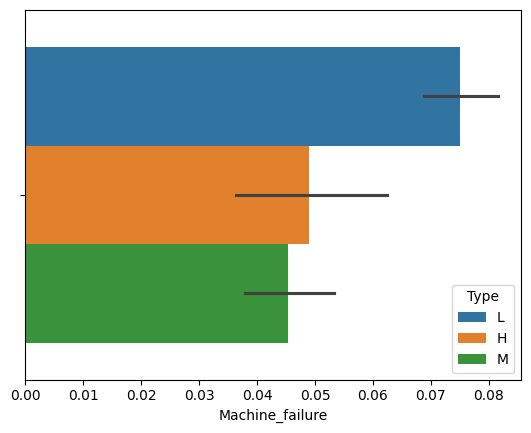

In [75]:
sns.barplot(data=df_copy,x='Machine_failure',hue='Type')
plt.show()

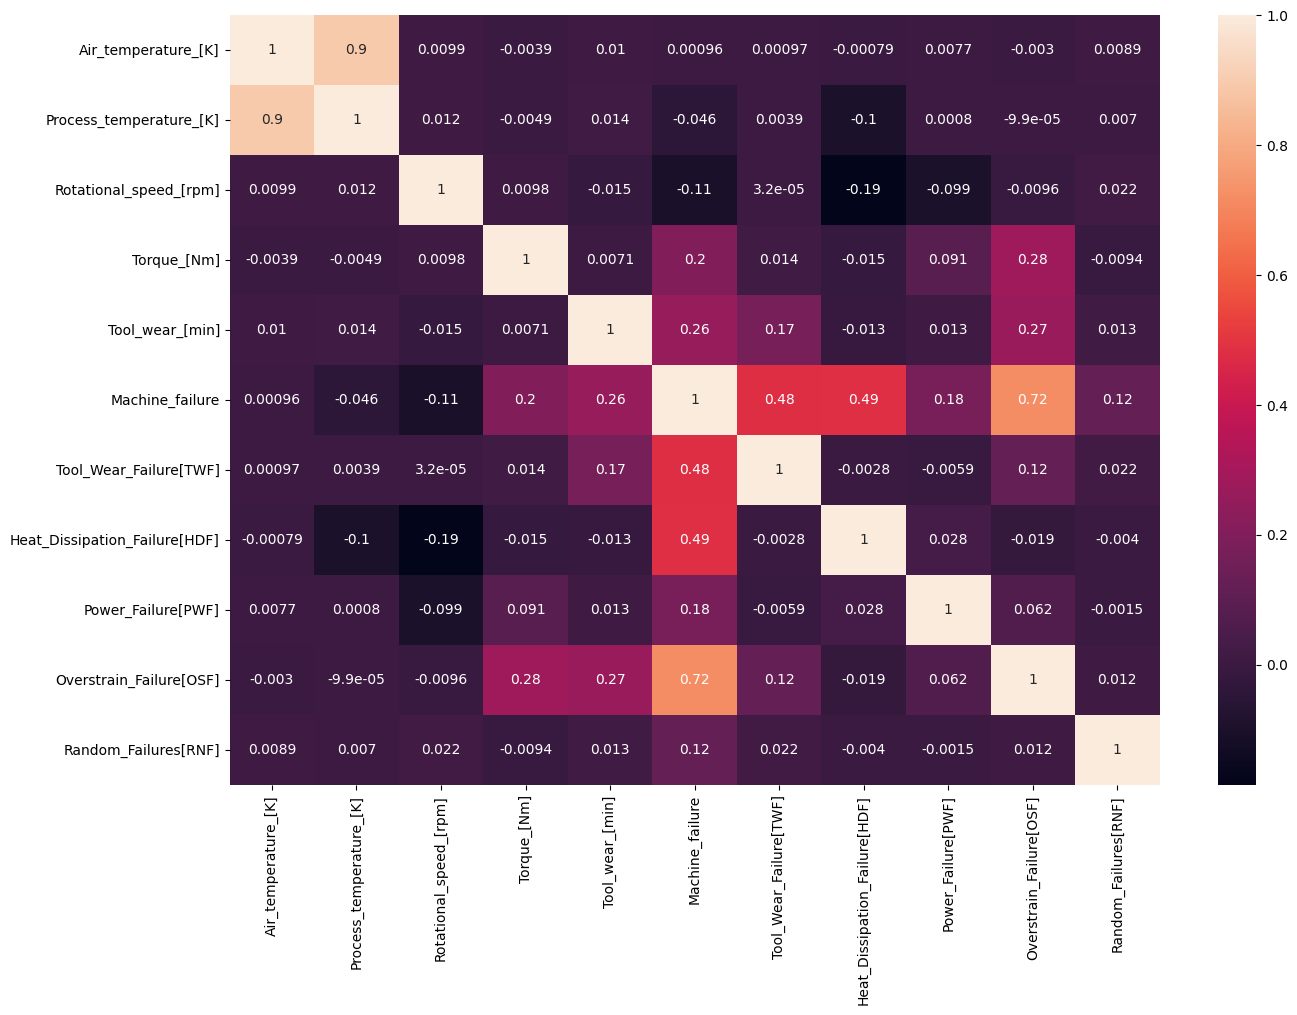

In [76]:
df_numerical =  df.select_dtypes(include='number')
df_numerical.drop(columns='UDI',inplace=True)
plt.figure(figsize=(15,10))
sns.heatmap(df_numerical.corr(),annot=True)
plt.show()

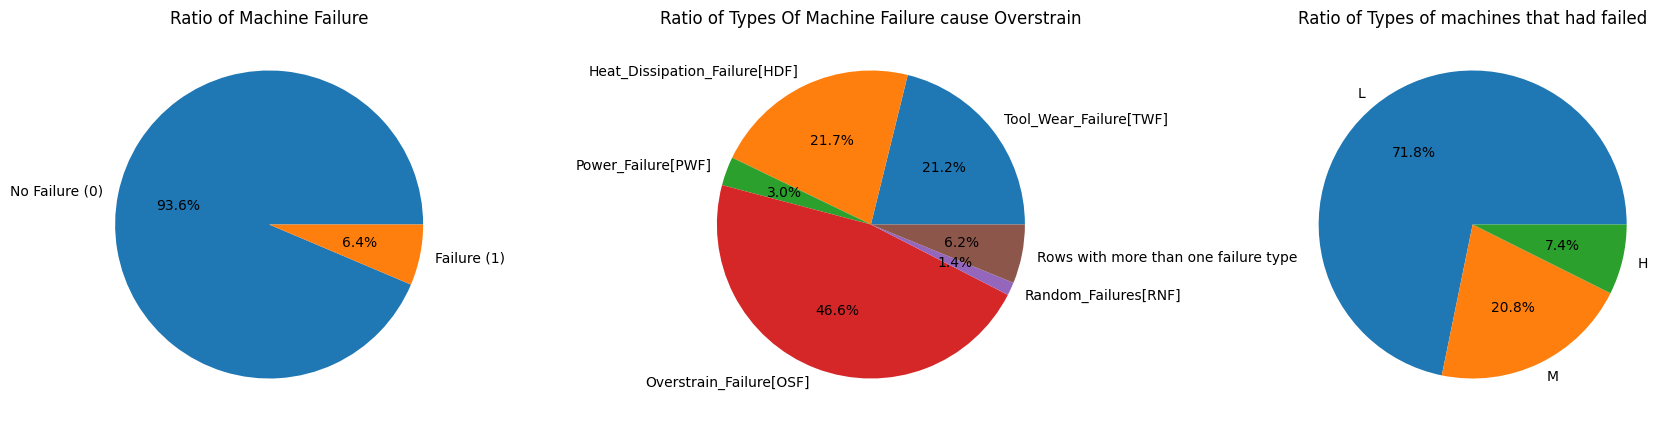

In [101]:
labels = ['Tool_Wear_Failure[TWF]', 'Heat_Dissipation_Failure[HDF]', 'Power_Failure[PWF]', 'Overstrain_Failure[OSF]', 'Random_Failures[RNF]','Rows with more than one failure type']
df_machine_failure = df[df['Machine_failure'] == 1]
count_Failure_type = [df_machine_failure[col].sum() /len(df_machine_failure) for col in failure_types]
combo_count = (df_machine_failure[failure_types].sum(axis=1) > 1).sum() / len(df_machine_failure)

count_Failure_type.append(combo_count)

fig,axis = plt.subplots(1,3,figsize=(22,5))
axis[0].set_title("Ratio of Machine Failure")
axis[0].pie(df_copy['Machine_failure'].value_counts(),labels=['No Failure (0)', 'Failure (1)'],autopct='%1.1f%%')


axis[1].set_title("Ratio of Types Of Machine Failure cause Overstrain")
axis[1].pie(count_Failure_type,labels=labels,autopct='%1.1f%%')

axis[2].set_title("Ratio of Types of machines that had failed")
axis[2].pie(df_machine_failure['Type'].value_counts(),labels=df_machine_failure.Type.value_counts().index,autopct='%1.1f%%')
plt.show()


In [102]:
df_cleaned = df.to_csv('df_cleaned.csv',index=False)